118 images × 39209 neurons
Ultrametricity score: 0.508


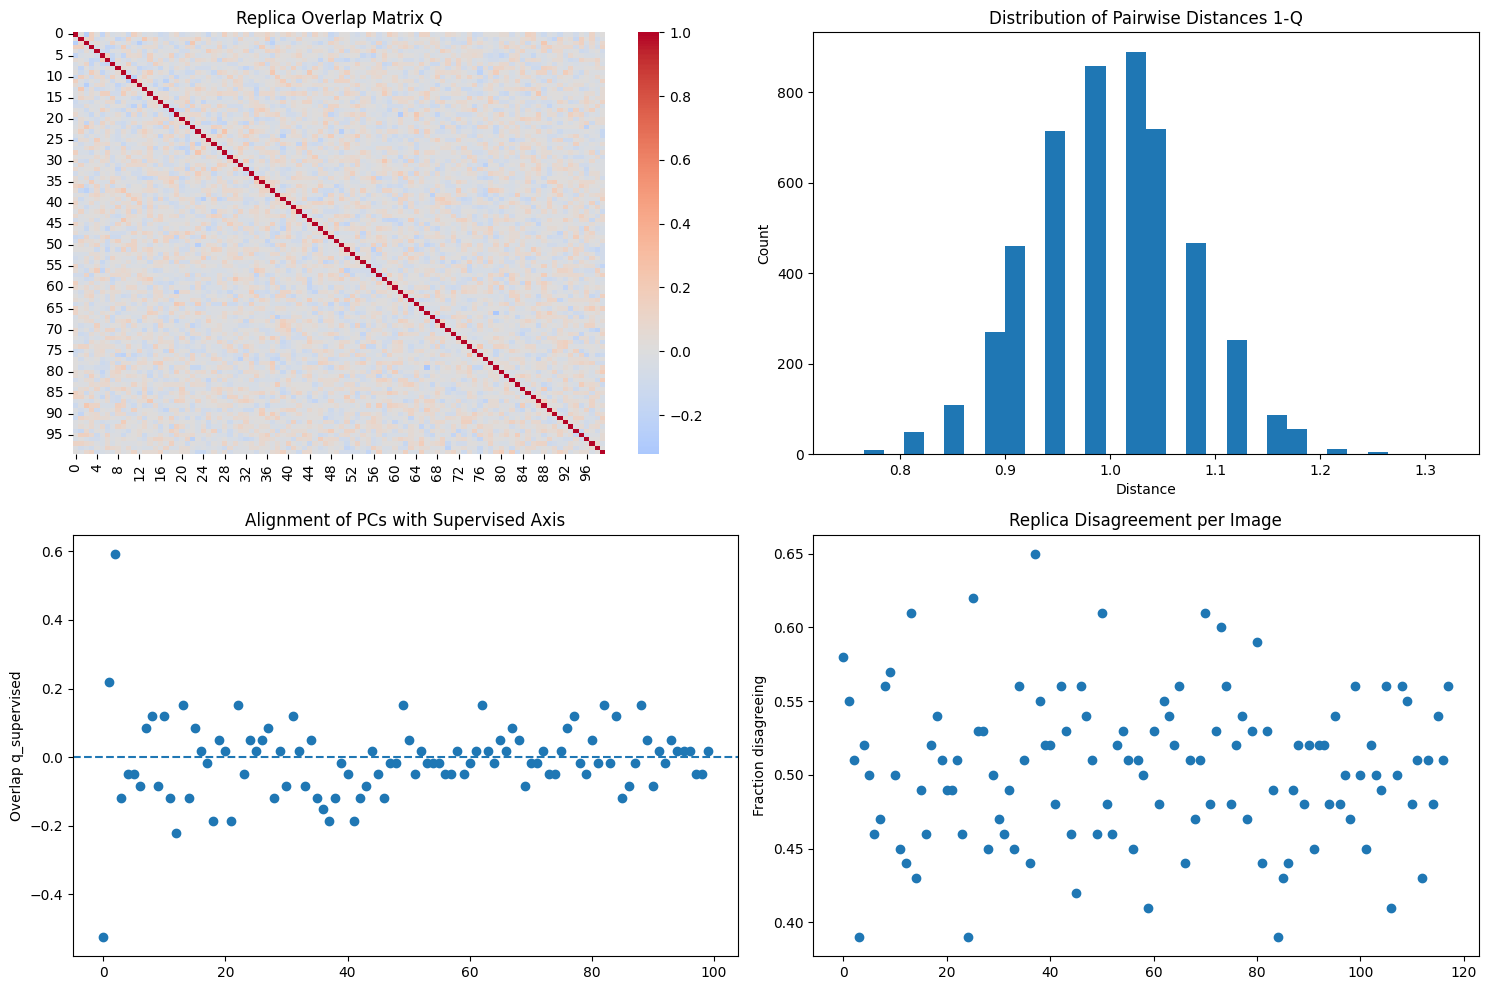

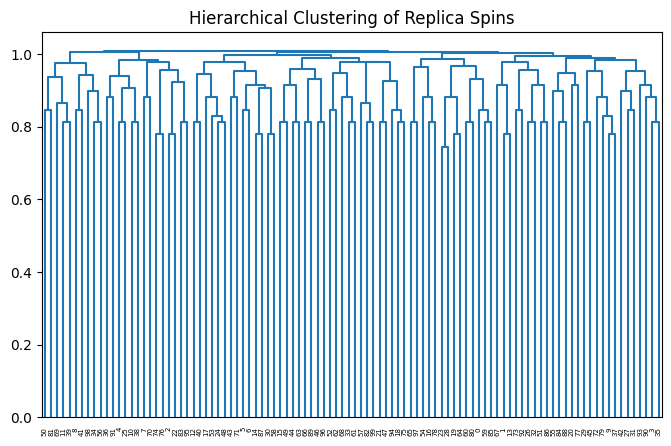

In [ ]:


"""
Variance geometry diagnostics for large neural populations
Animate vs Inanimate decoding (ImageNet labels)

LOO logistic regression fields
PCA of field variability
Safe for ~20k–40k neurons (no NxN covariance matrices)
"""

import numpy as np
import matplotlib.pyplot as plt

from joblib import Parallel, delayed
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

# ============================================================
# PATHS
# ============================================================

VIT_PATH    = '/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl'
NEURAL_PATH = '/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy'
AREAS_PATH  = '/home/maria/ProjectionSort/data/brain_area.npy'

# ============================================================
# LOAD DATA
# ============================================================

vit   = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']   # (images, 1000)
R     = np.load(NEURAL_PATH).T                                   # (images, neurons)
areas = np.load(AREAS_PATH, allow_pickle=True)

n_images, n_neurons = R.shape
print(f"{n_images} images × {n_neurons} neurons")

# ============================================================
# IMAGE-NET ANIMATE / INANIMATE LABEL
# ============================================================

top1 = np.argmax(vit, axis=1)
y = (top1 <= 397).astype(int)   # 1 = animate, 0 = inanimate

# ============================================================
# REPLICA SPIN GLASS ANALYSIS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from itertools import combinations
import seaborn as sns

np.random.seed(0)

# ============================================================
# 1) PREPROCESS VIT EMBEDDINGS
# ============================================================

X = vit.copy()  # (images, 1000)
X = StandardScaler().fit_transform(X)

n_images, d = X.shape

# ============================================================
# 2) SUPERVISED LOGISTIC AXIS (animate vs inanimate)
# ============================================================

# Assuming binary labels exist in your workflow
# If not, replace y with your actual labels
y = np.array([1 if i < n_images//2 else 0 for i in range(n_images)])

clf = LogisticRegression(max_iter=1000)
clf.fit(X, y)

w = clf.coef_.ravel()
b = clf.intercept_[0]

logit_scores = X @ w + b
supervised_spins = np.sign(logit_scores)
supervised_spins[supervised_spins == 0] = 1

# ============================================================
# 3) SEMANTIC PC REPLICAS
# ============================================================

K = 100  # number of PCs (replicas)

pca = PCA(n_components=K)
X_pca = pca.fit_transform(X)

# Median threshold spins
replicas = np.sign(X_pca - np.median(X_pca, axis=0))
replicas[replicas == 0] = 1  # avoid zeros

# replicas shape: (images, K)

# ============================================================
# 4) OVERLAP MATRIX Q
# ============================================================

Q = (replicas.T @ replicas) / n_images  # (K, K)

# ============================================================
# 5) ALIGNMENT WITH SUPERVISED AXIS
# ============================================================

q_supervised = (replicas.T @ supervised_spins) / n_images

# ============================================================
# 6) DISAGREEMENT HOTSPOTS
# ============================================================

# For each image: how many replicas disagree with supervised axis?
disagreement = np.mean(replicas != supervised_spins[:, None], axis=1)

# ============================================================
# 7) ULTRAMETRICITY TEST
# ============================================================

# Distance matrix
D = 1 - Q
tri_indices = np.triu_indices(K, k=1)
dist_values = D[tri_indices]

# Sample random triples
n_triplets = 2000
triplets = np.random.choice(K, size=(n_triplets, 3))

ultra_count = 0
delta = 0.05

for a, b_, c in triplets:
    d_ab = D[a, b_]
    d_ac = D[a, c]
    d_bc = D[b_, c]
    d_sorted = np.sort([d_ab, d_ac, d_bc])
    if abs(d_sorted[2] - d_sorted[1]) < delta:
        ultra_count += 1

ultra_score = ultra_count / n_triplets
print(f"Ultrametricity score: {ultra_score:.3f}")

# ============================================================
# 8) PLOTS
# ============================================================

plt.figure(figsize=(15, 10))

# ---- Heatmap of overlaps ----
plt.subplot(2,2,1)
sns.heatmap(Q, cmap='coolwarm', center=0)
plt.title("Replica Overlap Matrix Q")

# ---- Histogram P(q) ----
plt.subplot(2,2,2)
plt.hist(dist_values, bins=30)
plt.title("Distribution of Pairwise Distances 1-Q")
plt.xlabel("Distance")
plt.ylabel("Count")

# ---- Alignment with supervised axis ----
plt.subplot(2,2,3)
plt.plot(q_supervised, 'o')
plt.axhline(0, linestyle='--')
plt.title("Alignment of PCs with Supervised Axis")
plt.ylabel("Overlap q_supervised")

# ---- Disagreement hotspots ----
plt.subplot(2,2,4)
plt.plot(disagreement, 'o')
plt.title("Replica Disagreement per Image")
plt.ylabel("Fraction disagreeing")

plt.tight_layout()
plt.show()

# ============================================================
# 9) HIERARCHICAL CLUSTERING
# ============================================================

linked = linkage(squareform(D), method='average')

plt.figure(figsize=(8,5))
dendrogram(linked)
plt.title("Hierarchical Clustering of Replica Spins")
plt.show()

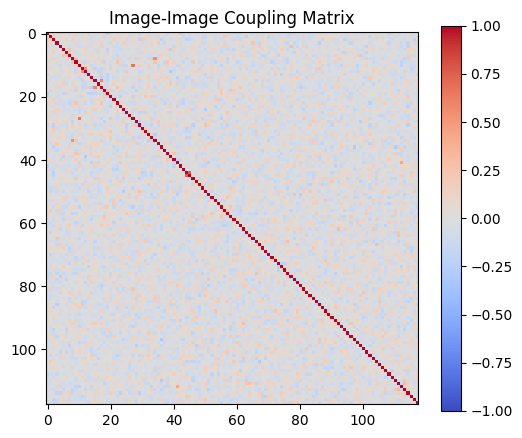

In [3]:
# image-image coupling from replica agreement
J_img = (replicas @ replicas.T) / K   # (images, images)

plt.figure(figsize=(6,5))
plt.imshow(J_img, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.title("Image-Image Coupling Matrix")
plt.show()

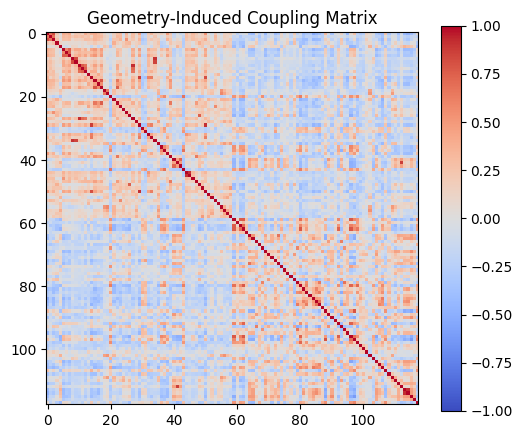

In [4]:
# Normalize embeddings
X_norm = X / np.linalg.norm(X, axis=1, keepdims=True)

J_geom = X_norm @ X_norm.T

plt.figure(figsize=(6,5))
plt.imshow(J_geom, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.title("Geometry-Induced Coupling Matrix")
plt.show()

Energy E(labeling) = -564.873
Fraction unstable (Δ_i < 0): 0.136
Null mean=-0.159, std=18.819
Z-score (lower is better) = -30.01
p(null <= E) = 0.0002  [small => labeling unusually low-energy]
corr(top eigenvector, spins) = -0.704


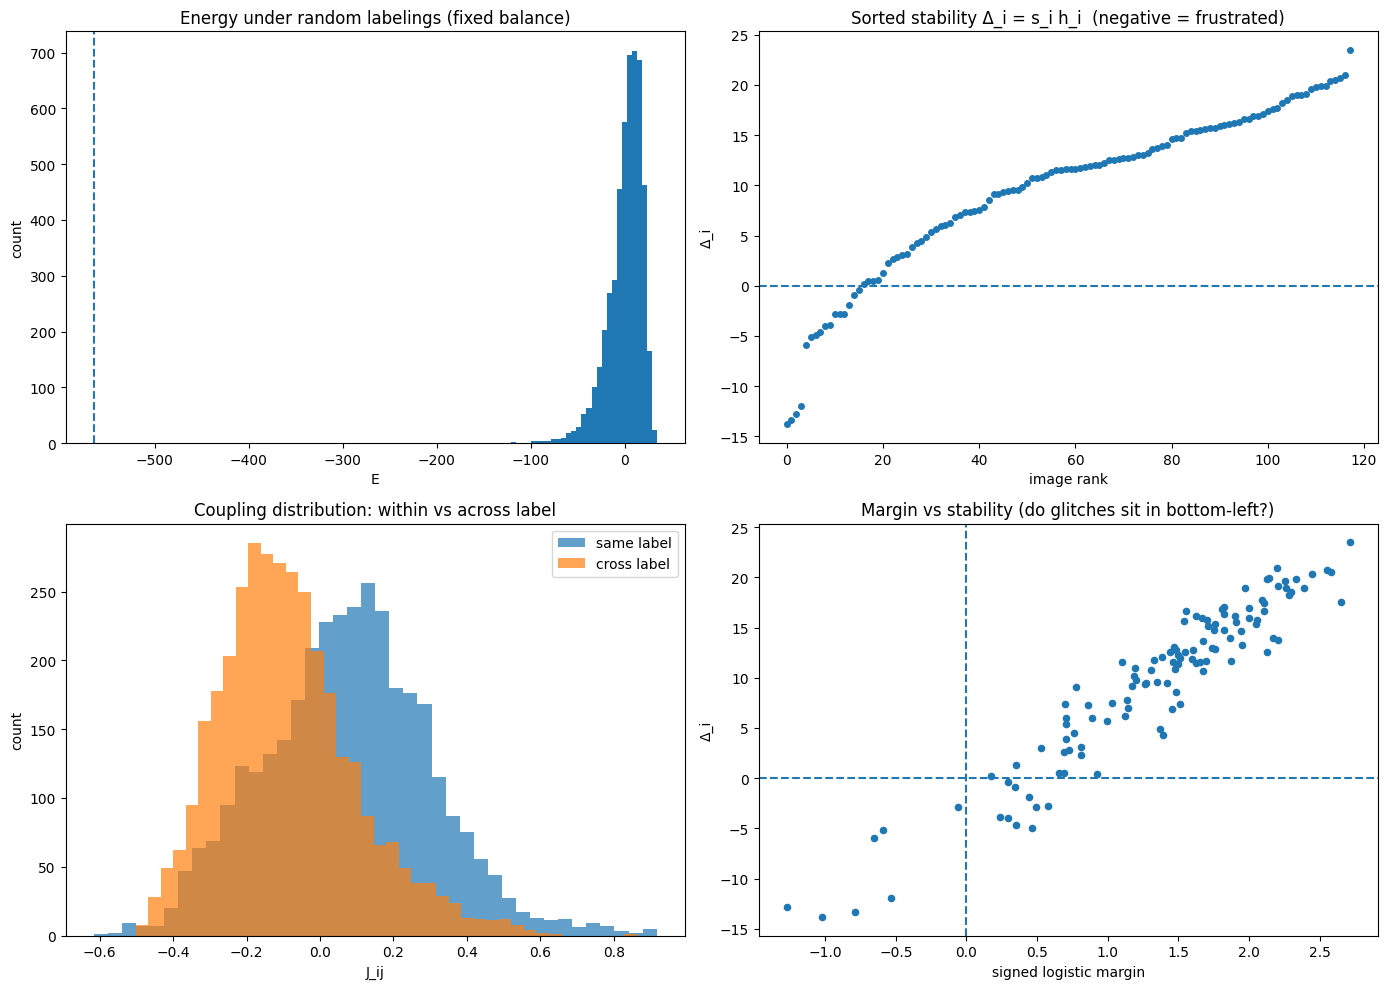

Most frustrated images (lowest Δ_i):
43 y= 1 Δ= -13.80662641617624 h= -13.80662641617624
31 y= 1 Δ= -13.360158689624663 h= -13.360158689624663
20 y= 1 Δ= -12.817641053490133 h= -12.817641053490133
30 y= 1 Δ= -11.951971490433314 h= -11.951971490433314
102 y= 0 Δ= -5.9385605646928905 h= 5.9385605646928905
40 y= 1 Δ= -5.14632756117155 h= -5.14632756117155
93 y= 0 Δ= -4.921787789935427 h= 4.921787789935427
107 y= 0 Δ= -4.63631146290836 h= 4.63631146290836
37 y= 1 Δ= -3.9816394963820403 h= -3.9816394963820403
78 y= 0 Δ= -3.887918515939092 h= 3.887918515939092
97 y= 0 Δ= -2.8439059685607395 h= 2.8439059685607395
112 y= 0 Δ= -2.8391052222288304 h= 2.8391052222288304
88 y= 0 Δ= -2.8045949652000597 h= 2.8045949652000597
76 y= 0 Δ= -1.9073348774640937 h= 1.9073348774640937
36 y= 1 Δ= -0.8745467614150287 h= -0.8745467614150287


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

np.random.seed(0)

# ------------------------------------------------------------
# 1) Build geometry-induced couplings J from logits
# ------------------------------------------------------------
X = vit.astype(np.float64)
X = StandardScaler().fit_transform(X)
X = X / np.linalg.norm(X, axis=1, keepdims=True)  # cosine geometry

J = X @ X.T
np.fill_diagonal(J, 0.0)  # remove self-coupling

n = J.shape[0]

# ------------------------------------------------------------
# 2) Convert your labels to spins s in {-1,+1}
# y: 1=animate, 0=inanimate
# ------------------------------------------------------------
s = (2*y - 1).astype(np.float64)  # 1 -> +1, 0 -> -1

# ------------------------------------------------------------
# 3) Energy and local fields
# ------------------------------------------------------------
# Energy: E = -1/2 * s^T J s
E = -0.5 * (s @ (J @ s))

# Local fields h_i = sum_j J_ij s_j
h = J @ s
stability = s * h  # Δ_i

print(f"Energy E(labeling) = {E:.3f}")
print(f"Fraction unstable (Δ_i < 0): {(stability < 0).mean():.3f}")

# ------------------------------------------------------------
# 4) Null distribution: random relabelings with fixed class balance
# ------------------------------------------------------------
B = 5000
E_null = np.empty(B, dtype=np.float64)

idx = np.arange(n)
n_pos = int((s == 1).sum())

for b in range(B):
    perm = np.random.permutation(idx)
    s_rand = np.full(n, -1.0)
    s_rand[perm[:n_pos]] = 1.0
    E_null[b] = -0.5 * (s_rand @ (J @ s_rand))

z = (E - E_null.mean()) / (E_null.std() + 1e-12)
p = (np.sum(E_null <= E) + 1) / (B + 1)  # lower energy is "more organized"

print(f"Null mean={E_null.mean():.3f}, std={E_null.std():.3f}")
print(f"Z-score (lower is better) = {z:.2f}")
print(f"p(null <= E) = {p:.4f}  [small => labeling unusually low-energy]")

# ------------------------------------------------------------
# 5) Coupling distributions: within-class vs across-class
# ------------------------------------------------------------
mask_same = (s[:, None] == s[None, :])
tri = np.triu(np.ones_like(J, dtype=bool), k=1)

J_same  = J[tri & mask_same]
J_cross = J[tri & (~mask_same)]

# ------------------------------------------------------------
# 6) Spectral alignment: top eigenvector vs spins
# ------------------------------------------------------------
# top eigenvector of J (symmetric)
vals, vecs = np.linalg.eigh(J)
v1 = vecs[:, -1]
corr = np.corrcoef(v1, s)[0, 1]
print(f"corr(top eigenvector, spins) = {corr:.3f}")

# ------------------------------------------------------------
# 7) Plots
# ------------------------------------------------------------
plt.figure(figsize=(14,10))

# A: energy null distribution
plt.subplot(2,2,1)
plt.hist(E_null, bins=40)
plt.axvline(E, linestyle="--")
plt.title("Energy under random labelings (fixed balance)")
plt.xlabel("E")
plt.ylabel("count")

# B: stability per image
plt.subplot(2,2,2)
plt.plot(np.sort(stability), 'o', markersize=4)
plt.axhline(0, linestyle="--")
plt.title("Sorted stability Δ_i = s_i h_i  (negative = frustrated)")
plt.xlabel("image rank")
plt.ylabel("Δ_i")

# C: coupling distributions
plt.subplot(2,2,3)
plt.hist(J_same, bins=40, alpha=0.7, label="same label")
plt.hist(J_cross, bins=40, alpha=0.7, label="cross label")
plt.title("Coupling distribution: within vs across label")
plt.xlabel("J_ij")
plt.ylabel("count")
plt.legend()

# D: scatter stability vs logistic margin (optional but gold)
# Fit logistic quickly just for margin; if you already have w,b use that
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(max_iter=2000).fit(X, y)
margin = (X @ clf.coef_.ravel() + clf.intercept_[0]) * (2*y - 1)

plt.subplot(2,2,4)
plt.scatter(margin, stability, s=20)
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")
plt.title("Margin vs stability (do glitches sit in bottom-left?)")
plt.xlabel("signed logistic margin")
plt.ylabel("Δ_i")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8) Print the most frustrated images (indices)
# ------------------------------------------------------------
k = 15
worst = np.argsort(stability)[:k]
print("Most frustrated images (lowest Δ_i):")
for i in worst:
    print(i, "y=", y[i], "Δ=", stability[i], "h=", h[i])

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

# ------------------------------------------------------------
# Data
# ------------------------------------------------------------
X_neural = torch.tensor(R, dtype=torch.float32)     # (n_images, n_neurons)
y_torch  = torch.tensor(y*2-1, dtype=torch.float32) # ±1

# J from ViT geometry (already computed)
J_torch = torch.tensor(J, dtype=torch.float32)

# Graph Laplacian
D = torch.diag(J_torch.sum(dim=1))
L = D - J_torch

# ------------------------------------------------------------
# Model
# ------------------------------------------------------------
w = torch.zeros(X_neural.shape[1], requires_grad=True)
optimizer = optim.Adam([w], lr=1e-2)

lambda_graph = 0.01

for epoch in range(500):

    optimizer.zero_grad()

    logits = X_neural @ w
    loss_logistic = torch.mean(torch.log(1 + torch.exp(-y_torch * logits)))

    loss_graph = lambda_graph * (logits @ (L @ logits)) / X_neural.shape[0]

    loss = loss_logistic + loss_graph
    loss.backward()
    optimizer.step()

print("Training done")

/home/maria/global_venv/lib/python3.12/site-packages/torch/autograd/graph.py:824: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Training done



Baseline accuracy: 0.7222
λ=0.00010   accuracy=0.7222
λ=0.00050   accuracy=0.7222
λ=0.00100   accuracy=0.7222
λ=0.00500   accuracy=0.7222
λ=0.01000   accuracy=0.7222


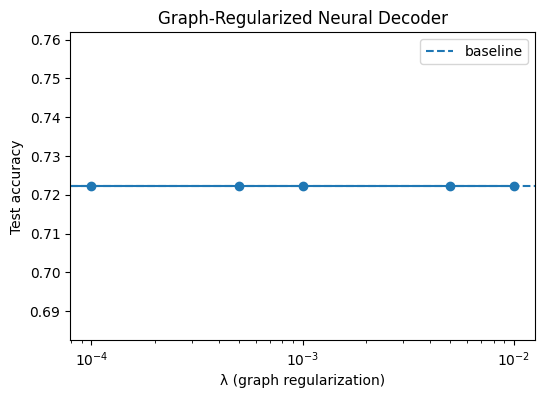


Best λ: 0.0
Best accuracy: 0.7222222222222222


In [8]:
# ============================================================
# GRAPH-REGULARIZED NEURAL DECODER
# ============================================================

import numpy as np
import torch
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

# ============================================================
# 1) BUILD GEOMETRY-INDUCED COUPLINGS J FROM VIT LOGITS
# ============================================================

X_vit = StandardScaler().fit_transform(vit.astype(np.float64))
X_vit = X_vit / np.linalg.norm(X_vit, axis=1, keepdims=True)

J = X_vit @ X_vit.T
np.fill_diagonal(J, 0.0)

# Normalize J to control scale
deg = J.sum(axis=1)
J = J / (deg.mean() + 1e-8)

# ============================================================
# 2) PREPARE NEURAL DATA
# ============================================================

R_std = StandardScaler().fit_transform(R)
n_images, n_neurons = R_std.shape

# Convert labels to ±1
s = 2*y - 1

# ============================================================
# 3) TRAIN / TEST SPLIT
# ============================================================

idx = np.arange(n_images)
train_idx, test_idx = train_test_split(
    idx, test_size=0.3, stratify=y, random_state=0
)

X_train = torch.tensor(R_std[train_idx], dtype=torch.float32)
X_test  = torch.tensor(R_std[test_idx], dtype=torch.float32)

y_train = torch.tensor(s[train_idx], dtype=torch.float32)
y_test  = torch.tensor(s[test_idx], dtype=torch.float32)

# Build Laplacian only on training data (no leakage)
J_train = torch.tensor(J[np.ix_(train_idx, train_idx)], dtype=torch.float32)
D_train = torch.diag(J_train.sum(dim=1))
L_train = D_train - J_train

# ============================================================
# 4) TRAINING FUNCTION
# ============================================================

def train_model(X, y, lambda_graph=0.0, L=None, epochs=800):

    w = torch.zeros(X.shape[1], requires_grad=True)
    optimizer = torch.optim.Adam([w], lr=5e-3)

    for _ in range(epochs):
        optimizer.zero_grad()

        logits = X @ w

        # Stable logistic loss
        loss = torch.mean(F.softplus(-y * logits))

        # Graph Laplacian regularization
        if lambda_graph > 0:
            logits_bounded = torch.tanh(logits)  # prevent explosion
            graph_term = (logits_bounded @ (L @ logits_bounded)) / X.shape[0]
            loss = loss + lambda_graph * graph_term

        loss.backward()
        optimizer.step()

    return w.detach()

# ============================================================
# 5) EVALUATION FUNCTION
# ============================================================

def evaluate(w):
    logits = (X_test @ w).numpy()
    preds = np.sign(logits)
    return accuracy_score(y_test.numpy(), preds)

# ============================================================
# 6) BASELINE
# ============================================================

w_base = train_model(X_train, y_train)
acc_base = evaluate(w_base)

print(f"\nBaseline accuracy: {acc_base:.4f}")

# ============================================================
# 7) GRAPH-REGULARIZED SWEEP
# ============================================================

lambdas = [0.0, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
accs = []

for lam in lambdas:
    if lam == 0.0:
        accs.append(acc_base)
        continue

    w_graph = train_model(X_train, y_train,
                          lambda_graph=lam,
                          L=L_train)

    acc = evaluate(w_graph)
    accs.append(acc)

    print(f"λ={lam:.5f}   accuracy={acc:.4f}")

# ============================================================
# 8) PLOT RESULTS
# ============================================================

plt.figure(figsize=(6,4))
plt.plot(lambdas, accs, marker='o')
plt.xscale("log")
plt.xlabel("λ (graph regularization)")
plt.ylabel("Test accuracy")
plt.title("Graph-Regularized Neural Decoder")
plt.axhline(acc_base, linestyle='--', label="baseline")
plt.legend()
plt.show()

# ============================================================
# 9) PRINT BEST RESULT
# ============================================================

best_idx = np.argmax(accs)
print("\nBest λ:", lambdas[best_idx])
print("Best accuracy:", accs[best_idx])

118 images × 39209 neurons
n=118, n_pos=63, n_neg=55
Top eigenvalues: λ1=1.2030, λ2=1.1664, gap=0.0366
corr(v1, s) (up to sign): -0.3999


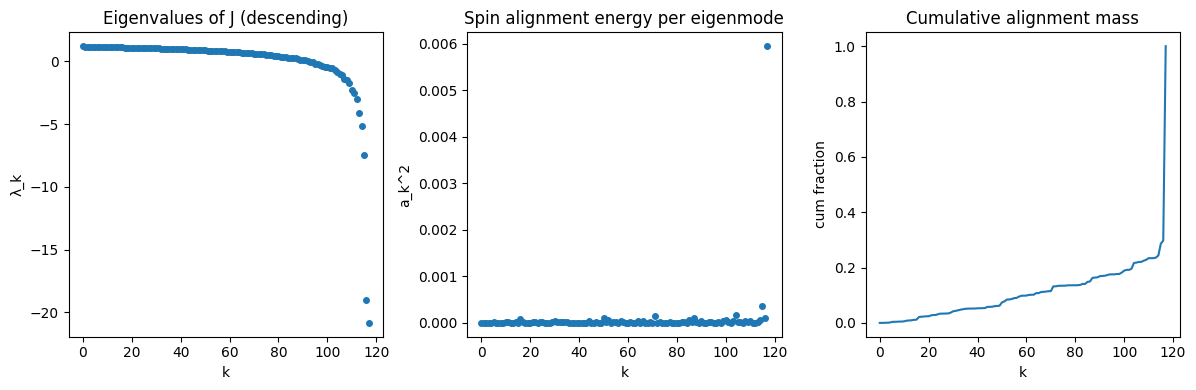

E(labeling)=893.380
Null mean=0.724, std=22.681, z=39.36, p(null<=E)=1.0000


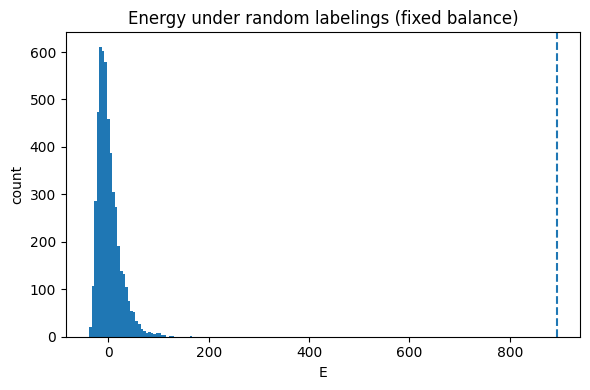

Fraction unstable (Δ_i<0): 0.915
Min stability: -32.669 | Max stability: 10.754


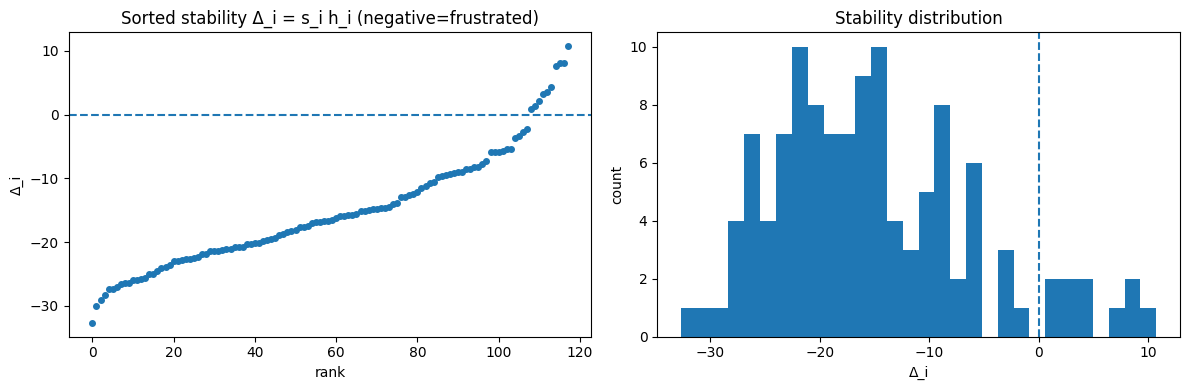


Most frustrated images (lowest Δ_i):
  idx=106 y=0 s=-1 Δ=-32.669  h=+32.669  ΔEflip=-65.338
  idx= 15 y=1 s=+1 Δ=-30.009  h=-30.009  ΔEflip=-60.017
  idx= 82 y=0 s=-1 Δ=-29.165  h=+29.165  ΔEflip=-58.331
  idx= 80 y=0 s=-1 Δ=-28.314  h=+28.314  ΔEflip=-56.627
  idx= 62 y=0 s=-1 Δ=-27.379  h=+27.379  ΔEflip=-54.758
  idx= 81 y=0 s=-1 Δ=-27.298  h=+27.298  ΔEflip=-54.595
  idx= 98 y=0 s=-1 Δ=-27.099  h=+27.099  ΔEflip=-54.198
  idx= 85 y=0 s=-1 Δ=-26.519  h=+26.519  ΔEflip=-53.037
  idx= 84 y=0 s=-1 Δ=-26.484  h=+26.484  ΔEflip=-52.968
  idx= 29 y=1 s=+1 Δ=-26.459  h=-26.459  ΔEflip=-52.917
  idx=  2 y=1 s=+1 Δ=-25.972  h=-25.972  ΔEflip=-51.944
  idx= 61 y=0 s=-1 Δ=-25.894  h=+25.894  ΔEflip=-51.787
  idx= 22 y=1 s=+1 Δ=-25.827  h=-25.827  ΔEflip=-51.653
  idx= 43 y=0 s=-1 Δ=-25.697  h=+25.697  ΔEflip=-51.394
  idx= 86 y=0 s=-1 Δ=-24.991  h=+24.991  ΔEflip=-49.982

Weighted edge satisfaction:
  satisfied:   0.201
  unsatisfied: 0.799
  zero:        0.000

Greedy descent from 1000 rand

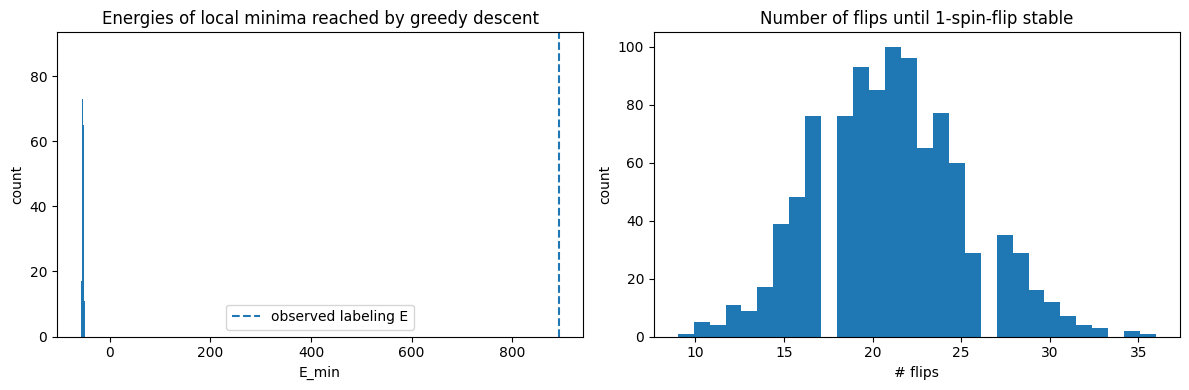

T=0.20  <E>=-58.43  Var(E)=4169.89  q=0.915
T=0.40  <E>=-52.29  Var(E)=8.74  q=-0.017
T=0.60  <E>=-47.87  Var(E)=5.36  q=-0.085
T=0.80  <E>=-45.07  Var(E)=7.07  q=-0.102
T=1.00  <E>=-42.80  Var(E)=10.48  q=0.051
T=1.20  <E>=-41.28  Var(E)=12.87  q=0.102
T=1.40  <E>=-40.05  Var(E)=11.28  q=0.102
T=1.60  <E>=-38.16  Var(E)=16.54  q=-0.017
T=1.80  <E>=-37.33  Var(E)=15.52  q=0.017
T=2.00  <E>=-36.84  Var(E)=22.42  q=0.136
T=2.20  <E>=-35.48  Var(E)=20.27  q=-0.034
T=2.40  <E>=-34.42  Var(E)=26.69  q=-0.068
T=2.60  <E>=-33.79  Var(E)=25.37  q=-0.102
T=2.80  <E>=-32.90  Var(E)=28.32  q=0.034
T=3.00  <E>=-31.92  Var(E)=33.82  q=-0.017


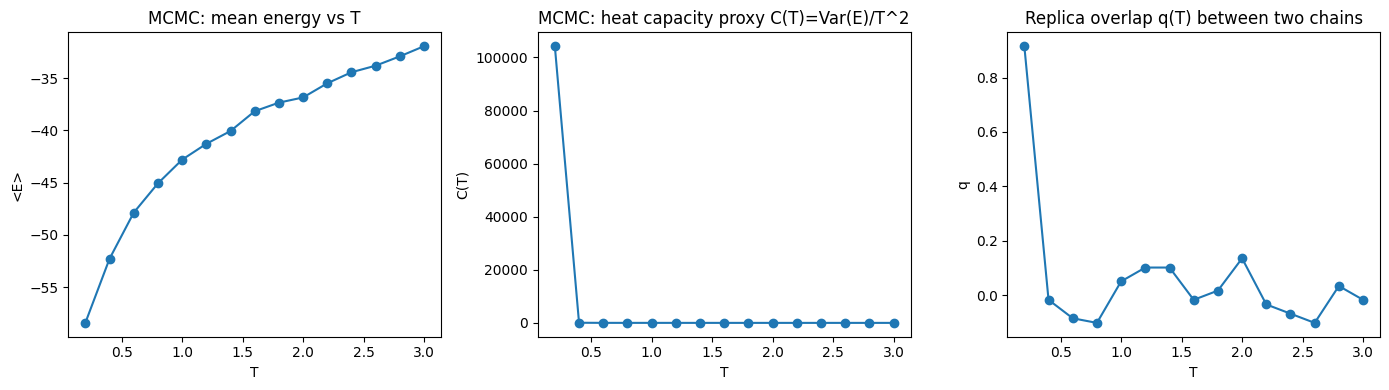


Done.


In [11]:
"""
Spin-glass-style analyses on an image-spin system with couplings J_ij.

Assumes you already loaded:
  vit: (n_images, d_logits)
  R:   (n_images, n_neurons)  [not used here, but ok]
  y:   (n_images,) with 1=animate, 0=inanimate

This script builds geometry-induced couplings from ViT logits:
  J_ij = cosine_similarity( standardized logits )
and then runs classical analyses:
  1) Spectrum + spectral gap, and spin alignment with eigenmodes
  2) Energy of labeling vs random label null
  3) Local fields, stabilities, flip-energy ΔE_i
  4) Frustration index: fraction of unsatisfied weighted edges
  5) Many-restart greedy descent (single-spin flip dynamics) to count local minima
  6) Optional: MCMC temperature sweep (E(T), C(T), q-overlap P(q))
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
"""
Variance geometry diagnostics for large neural populations
Animate vs Inanimate decoding (ImageNet labels)

LOO logistic regression fields
PCA of field variability
Safe for ~20k–40k neurons (no NxN covariance matrices)
"""

import numpy as np
import matplotlib.pyplot as plt

from joblib import Parallel, delayed
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

# ============================================================
# PATHS
# ============================================================

VIT_PATH    = '/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl'
NEURAL_PATH = '/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy'
AREAS_PATH  = '/home/maria/ProjectionSort/data/brain_area.npy'

# ============================================================
# LOAD DATA
# ============================================================

vit   = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']   # (images, 1000)
R     = np.load(NEURAL_PATH).T                                   # (images, neurons)
areas = np.load(AREAS_PATH, allow_pickle=True)

n_images, n_neurons = R.shape
print(f"{n_images} images × {n_neurons} neurons")

# ============================================================
# IMAGE-NET ANIMATE / INANIMATE LABEL
# ============================================================

top1 = np.argmax(vit, axis=1)
y = (top1 <= 397).astype(int)   # 1 = animate, 0 = inanimate


# ----------------------------
# Helpers
# ----------------------------

def build_J_from_vit_logits(vit_logits: np.ndarray, normalize_by_mean_degree=True):
    """
    Build dense symmetric couplings J from standardized logits using cosine similarity.
    """
    X = StandardScaler().fit_transform(vit_logits.astype(np.float64))
    X = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)  # cosine normalization

    J = X @ X.T
    np.fill_diagonal(J, 0.0)

    # Optional scaling to make magnitudes comparable across datasets
    if normalize_by_mean_degree:
        deg = J.sum(axis=1)
        J = J / (deg.mean() + 1e-12)

    # Ensure exact symmetry (numerical)
    J = 0.5 * (J + J.T)
    return J


def labels_to_spins(y01: np.ndarray):
    """0/1 -> -1/+1"""
    s = (2*y01 - 1).astype(np.int8)
    return s


def energy(J: np.ndarray, s: np.ndarray):
    """
    E(s) = -1/2 s^T J s  (with diag(J)=0)
    """
    s = s.astype(np.float64)
    return -0.5 * (s @ (J @ s))


def local_fields(J: np.ndarray, s: np.ndarray):
    """h_i = sum_j J_ij s_j"""
    return J @ s.astype(np.float64)


def frustration_index(J: np.ndarray, s: np.ndarray):
    """
    Weighted fraction of unsatisfied edges:
      satisfied if J_ij * s_i * s_j > 0
    Return:
      frac_unsatisfied_weighted, frac_satisfied_weighted
    """
    n = len(s)
    tri = np.triu_indices(n, k=1)
    Jij = J[tri]
    sisj = (s[tri[0]] * s[tri[1]]).astype(np.float64)
    prod = Jij * sisj

    w = np.abs(Jij)
    total_w = w.sum() + 1e-12

    unsat_w = w[prod < 0].sum()
    sat_w   = w[prod > 0].sum()
    zero_w  = w[prod == 0].sum()

    return unsat_w / total_w, sat_w / total_w, zero_w / total_w


def greedy_descent_single_spin(J: np.ndarray, s0: np.ndarray, max_sweeps=5000):
    """
    Classic zero-temperature (T=0) single-spin flip descent:
      Flip any spin with negative stability Δ_i = s_i h_i < 0
    until no improving flips remain (1-spin-flip stable).
    Returns: s_final, E_final, n_flips
    """
    s = s0.copy().astype(np.int8)
    n = len(s)

    flips = 0
    for _ in range(max_sweeps):
        h = local_fields(J, s)
        stability = s.astype(np.float64) * h  # Δ_i
        bad = np.where(stability < 0)[0]
        if bad.size == 0:
            break

        # Flip the most unstable spin (steepest descent)
        i = bad[np.argmin(stability[bad])]
        s[i] *= -1
        flips += 1

    return s, energy(J, s), flips


def random_spin_config(n, n_pos=None, rng=None):
    """
    Random ±1 spins. If n_pos is set, enforce exactly n_pos spins = +1.
    """
    rng = np.random.default_rng() if rng is None else rng
    if n_pos is None:
        s = rng.choice([-1, 1], size=n).astype(np.int8)
        return s
    idx = rng.permutation(n)
    s = np.full(n, -1, dtype=np.int8)
    s[idx[:n_pos]] = 1
    return s


def mcmc_glauber(J: np.ndarray, beta: float, n_steps: int, s_init=None, rng=None):
    """
    Simple Glauber dynamics:
      Pick random i, propose flip, accept with p = 1/(1+exp(ΔE))
    where ΔE = 2 s_i h_i * beta? Actually in energy units:
      ΔE = 2 s_i h_i
      Accept with probability min(1, exp(-beta * ΔE))
    Returns trajectory energy samples (subsampled) and final s.
    """
    rng = np.random.default_rng() if rng is None else rng
    n = J.shape[0]
    s = random_spin_config(n, rng=rng) if s_init is None else s_init.copy().astype(np.int8)

    # Precompute fields for speed
    h = local_fields(J, s)

    E_samples = []
    sample_every = max(1, n_steps // 200)  # cap samples ~200

    for t in range(n_steps):
        i = rng.integers(0, n)

        # ΔE for flipping i: 2 s_i h_i (since diag(J)=0)
        dE = 2.0 * s[i] * h[i]

        # Metropolis acceptance
        if dE <= 0 or rng.random() < np.exp(-beta * dE):
            # flip
            si_old = s[i]
            s[i] = -s[i]
            # update fields h_k += -2 * si_old * J_{k,i}
            h += -2.0 * si_old * J[:, i]

        if t % sample_every == 0:
            E_samples.append(energy(J, s))

    return np.array(E_samples), s


def overlap(s1: np.ndarray, s2: np.ndarray):
    """q = (1/n) sum_i s1_i s2_i"""
    return float(np.mean(s1.astype(np.float64) * s2.astype(np.float64)))


# ----------------------------
# Build J and spins s
# ----------------------------

J = build_J_from_vit_logits(vit, normalize_by_mean_degree=True)
s = labels_to_spins(y)

n = len(s)
n_pos = int((s == 1).sum())
print(f"n={n}, n_pos={n_pos}, n_neg={n-n_pos}")

# ----------------------------
# 1) Spectrum + alignment
# ----------------------------

evals, evecs = np.linalg.eigh(J)  # ascending
evals = evals[::-1]
evecs = evecs[:, ::-1]

# Alignments a_k = (1/n) s^T v_k
align = (s.astype(np.float64) @ evecs) / n
align2 = align**2

gap = evals[0] - evals[1] if len(evals) > 1 else np.nan
print(f"Top eigenvalues: λ1={evals[0]:.4f}, λ2={evals[1]:.4f}, gap={gap:.4f}")
print(f"corr(v1, s) (up to sign): {np.corrcoef(evecs[:,0], s)[0,1]:.4f}")

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(evals, 'o', markersize=4)
plt.title("Eigenvalues of J (descending)")
plt.xlabel("k")
plt.ylabel("λ_k")

plt.subplot(1,3,2)
plt.plot(align2, 'o', markersize=4)
plt.title("Spin alignment energy per eigenmode")
plt.xlabel("k")
plt.ylabel("a_k^2")

plt.subplot(1,3,3)
plt.plot(np.cumsum(align2)/np.sum(align2 + 1e-12), '-')
plt.title("Cumulative alignment mass")
plt.xlabel("k")
plt.ylabel("cum fraction")
plt.tight_layout()
plt.show()

# ----------------------------
# 2) Energy vs null (fixed balance)
# ----------------------------

E_obs = energy(J, s)
B = 5000
rng = np.random.default_rng(0)
E_null = np.array([energy(J, random_spin_config(n, n_pos=n_pos, rng=rng)) for _ in range(B)])

z = (E_obs - E_null.mean()) / (E_null.std() + 1e-12)
p = (np.sum(E_null <= E_obs) + 1) / (B + 1)

print(f"E(labeling)={E_obs:.3f}")
print(f"Null mean={E_null.mean():.3f}, std={E_null.std():.3f}, z={z:.2f}, p(null<=E)={p:.4f}")

plt.figure(figsize=(6,4))
plt.hist(E_null, bins=40)
plt.axvline(E_obs, linestyle="--")
plt.title("Energy under random labelings (fixed balance)")
plt.xlabel("E")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# ----------------------------
# 3) Local fields, stability, flip-energy
# ----------------------------

h = local_fields(J, s)
stability = s.astype(np.float64) * h       # Δ_i
dE_flip = 2.0 * stability                  # ΔE_i for flipping

frac_unstable = float(np.mean(stability < 0))
print(f"Fraction unstable (Δ_i<0): {frac_unstable:.3f}")
print(f"Min stability: {stability.min():.3f} | Max stability: {stability.max():.3f}")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(np.sort(stability), 'o', markersize=4)
plt.axhline(0, linestyle='--')
plt.title("Sorted stability Δ_i = s_i h_i (negative=frustrated)")
plt.xlabel("rank")
plt.ylabel("Δ_i")

plt.subplot(1,2,2)
plt.hist(stability, bins=30)
plt.axvline(0, linestyle='--')
plt.title("Stability distribution")
plt.xlabel("Δ_i")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# Print most frustrated images
k = 15
worst = np.argsort(stability)[:k]
print("\nMost frustrated images (lowest Δ_i):")
for i in worst:
    print(f"  idx={i:3d} y={y[i]} s={s[i]:+d} Δ={stability[i]:+.3f}  h={h[i]:+.3f}  ΔEflip={dE_flip[i]:+.3f}")

# ----------------------------
# 4) Frustration index (edge satisfaction)
# ----------------------------

unsat, sat, zero = frustration_index(J, s)
print(f"\nWeighted edge satisfaction:")
print(f"  satisfied:   {sat:.3f}")
print(f"  unsatisfied: {unsat:.3f}")
print(f"  zero:        {zero:.3f}")

# ----------------------------
# 5) Many-restart greedy descent: local minima landscape
# ----------------------------

n_restarts = 1000
minima = {}  # key=rounded energy -> count
flip_counts = []
energies = []

for r in range(n_restarts):
    s0 = random_spin_config(n, n_pos=n_pos, rng=rng)
    sf, Ef, flips = greedy_descent_single_spin(J, s0, max_sweeps=10000)
    energies.append(Ef)
    flip_counts.append(flips)

    key = round(Ef, 6)
    minima[key] = minima.get(key, 0) + 1

energies = np.array(energies)
flip_counts = np.array(flip_counts)

unique_minima = len(minima)
top10 = sorted(minima.items(), key=lambda kv: kv[1], reverse=True)[:10]

print(f"\nGreedy descent from {n_restarts} random inits:")
print(f"  unique 1-spin-flip minima found: {unique_minima}")
print(f"  mean flips: {flip_counts.mean():.2f}  median flips: {np.median(flip_counts):.2f}")
print("  Top minima (energy -> count):")
for Ekey, c in top10:
    print(f"    {Ekey: .6f} -> {c}")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(energies, bins=30)
plt.axvline(E_obs, linestyle="--", label="observed labeling E")
plt.title("Energies of local minima reached by greedy descent")
plt.xlabel("E_min")
plt.ylabel("count")
plt.legend()

plt.subplot(1,2,2)
plt.hist(flip_counts, bins=30)
plt.title("Number of flips until 1-spin-flip stable")
plt.xlabel("# flips")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# ----------------------------
# 6) OPTIONAL: MCMC temperature sweep (E(T), C(T), overlaps)
# ----------------------------

DO_MCMC = True   # set False if you want it faster

if DO_MCMC:
    temps = np.linspace(0.2, 3.0, 15)
    E_mean = []
    E_var = []
    q_means = []

    rng2 = np.random.default_rng(123)

    # Start from observed labeling as init (can also use random)
    s_init = s.copy()

    for T in temps:
        beta = 1.0 / T
        # Burn-in + sampling steps
        E_samples, s_final = mcmc_glauber(J, beta=beta, n_steps=50000, s_init=s_init, rng=rng2)

        E_mean.append(E_samples.mean())
        E_var.append(E_samples.var())

        # Overlap with a second independent chain (classic P(q) idea)
        _, s_final2 = mcmc_glauber(J, beta=beta, n_steps=50000, s_init=None, rng=rng2)
        q_means.append(overlap(s_final, s_final2))

        # Warm-start next temperature (annealing-ish)
        s_init = s_final

        print(f"T={T:.2f}  <E>={E_samples.mean():.2f}  Var(E)={E_samples.var():.2f}  q={q_means[-1]:.3f}")

    E_mean = np.array(E_mean)
    E_var = np.array(E_var)
    q_means = np.array(q_means)

    C = E_var / (temps**2 + 1e-12)

    plt.figure(figsize=(14,4))
    plt.subplot(1,3,1)
    plt.plot(temps, E_mean, marker='o')
    plt.title("MCMC: mean energy vs T")
    plt.xlabel("T")
    plt.ylabel("<E>")

    plt.subplot(1,3,2)
    plt.plot(temps, C, marker='o')
    plt.title("MCMC: heat capacity proxy C(T)=Var(E)/T^2")
    plt.xlabel("T")
    plt.ylabel("C(T)")

    plt.subplot(1,3,3)
    plt.plot(temps, q_means, marker='o')
    plt.title("Replica overlap q(T) between two chains")
    plt.xlabel("T")
    plt.ylabel("q")

    plt.tight_layout()
    plt.show()

print("\nDone.")

n=118, n_pos=63, n_neg=55

================ SIGNED GLASS ================

E_obs = -35.270
Null mean = -0.022, std = 0.894
Z-score = -39.42
Fraction unstable spins = 0.085
Satisfied edges = 0.799
Unsatisfied edges = 0.201
Unique local minima (500 restarts) = 4


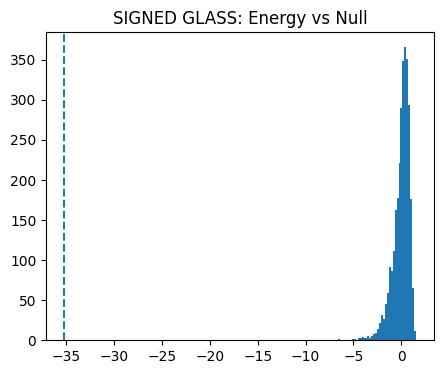


================ FERROMAGNETIC (POSITIVE ONLY) ================

E_obs = -18.345
Null mean = 0.112, std = 0.550
Z-score = -33.53
Fraction unstable spins = 0.076
Satisfied edges = 0.824
Unsatisfied edges = 0.176
Unique local minima (500 restarts) = 12


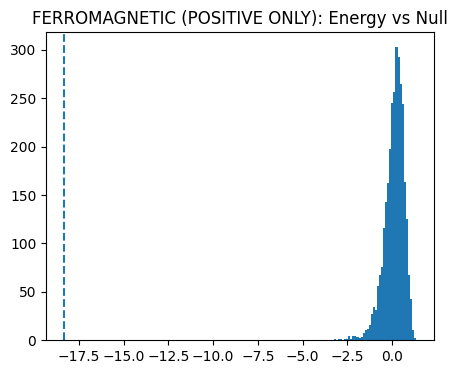

In [12]:
"""
Image Spin System Analysis
Signed spin glass vs Ferromagnetic similarity graph
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ============================================================
# LOAD DATA (assumes you already defined vit and y properly)
# ============================================================

# vit: (n_images, d_logits)
# y:   binary 0/1 animate/inanimate

# Convert labels to spins ±1
s = (2*y - 1).astype(np.int8)
n = len(s)
n_pos = (s == 1).sum()

print(f"n={n}, n_pos={n_pos}, n_neg={n-n_pos}")

# ============================================================
# BUILD COSINE COUPLING MATRIX
# ============================================================

X = StandardScaler().fit_transform(vit.astype(np.float64))
X = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)

J = X @ X.T
np.fill_diagonal(J, 0.0)

# SIGNED-SAFE NORMALIZATION (absolute degree)
scale = np.mean(np.sum(np.abs(J), axis=1)) + 1e-12
J = J / scale

J = 0.5 * (J + J.T)

# Two models
J_signed = J.copy()
J_pos = np.maximum(J, 0.0)

# ============================================================
# ENERGY FUNCTION
# ============================================================

def energy(J, s):
    return -0.5 * s @ (J @ s)

def local_fields(J, s):
    return J @ s

def frustration(J, s):
    tri = np.triu_indices(len(s), k=1)
    Jij = J[tri]
    sisj = s[tri[0]] * s[tri[1]]
    w = np.abs(Jij)
    total = w.sum() + 1e-12
    unsat = w[Jij * sisj < 0].sum()
    sat   = w[Jij * sisj > 0].sum()
    return sat/total, unsat/total

def random_spin_config(n, n_pos, rng):
    idx = rng.permutation(n)
    s = np.full(n, -1, dtype=np.int8)
    s[idx[:n_pos]] = 1
    return s

def greedy_descent(J, s0):
    s = s0.copy()
    flips = 0
    while True:
        h = local_fields(J, s)
        stab = s * h
        bad = np.where(stab < 0)[0]
        if len(bad) == 0:
            break
        i = bad[np.argmin(stab[bad])]
        s[i] *= -1
        flips += 1
    return s, energy(J, s), flips

# ============================================================
# ANALYSIS FUNCTION
# ============================================================

def analyze(J, name):

    print(f"\n================ {name} ================\n")

    rng = np.random.default_rng(0)

    # Energy vs null
    E_obs = energy(J, s)
    E_null = np.array([
        energy(J, random_spin_config(n, n_pos, rng))
        for _ in range(3000)
    ])
    z = (E_obs - E_null.mean()) / (E_null.std() + 1e-12)

    print(f"E_obs = {E_obs:.3f}")
    print(f"Null mean = {E_null.mean():.3f}, std = {E_null.std():.3f}")
    print(f"Z-score = {z:.2f}")

    # Stability
    h = local_fields(J, s)
    frac_unstable = np.mean(s * h < 0)
    print(f"Fraction unstable spins = {frac_unstable:.3f}")

    # Frustration
    sat, unsat = frustration(J, s)
    print(f"Satisfied edges = {sat:.3f}")
    print(f"Unsatisfied edges = {unsat:.3f}")

    # Greedy landscape
    minima = {}
    for _ in range(500):
        s0 = random_spin_config(n, n_pos, rng)
        sf, Ef, _ = greedy_descent(J, s0)
        key = round(Ef, 6)
        minima[key] = minima.get(key, 0) + 1

    print(f"Unique local minima (500 restarts) = {len(minima)}")

    # Histogram energy null
    plt.figure(figsize=(5,4))
    plt.hist(E_null, bins=40)
    plt.axvline(E_obs, linestyle="--")
    plt.title(f"{name}: Energy vs Null")
    plt.show()

# ============================================================
# RUN BOTH SYSTEMS
# ============================================================

analyze(J_signed, "SIGNED GLASS")
analyze(J_pos, "FERROMAGNETIC (POSITIVE ONLY)")